In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical using the min max scaling
scaler = RobustScaler()  
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

# Clustering

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

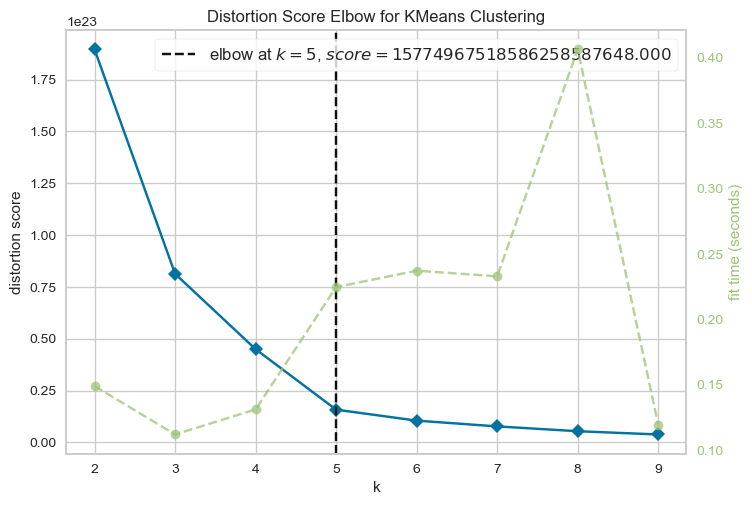

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: gldm_GrayLevelNonUniformity_d_1_PET_c04, Coefficient: 0.26931073416563733


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: glszm_LargeAreaLowGrayLevelEmphasis_PET_c04, Coefficient: 0.00150259687345959


...

Cluster 2: Most important feature: glcm_Correlation_d_1_CT_c16, Coefficient: 2.0114597022008756


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 3: Most important feature: glszm_LargeAreaEmphasis_PET_c04, Coefficient: 0.12560939991651457


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 4: Most important feature: glrlm_ShortRunLowGrayLevelEmphasis_CT_b20, Coefficient: -1.932162935095698


In [21]:
selected_features

['gldm_GrayLevelNonUniformity_d_1_PET_c04',
 'glszm_LargeAreaLowGrayLevelEmphasis_PET_c04',
 'glcm_Correlation_d_1_CT_c16',
 'glszm_LargeAreaEmphasis_PET_c04',
 'glrlm_ShortRunLowGrayLevelEmphasis_CT_b20']

In [22]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [23]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [24]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [25]:
X_new

,gldm_GrayLevelNonUniformity_d_1_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaEmphasis_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20
0,2305.801653,879096.343994,0.712490,3.392207e+06,0.000536
1,487.679707,26566.901706,0.523607,9.996325e+04,0.001324
2,4412.632895,647295.586841,0.660634,4.566579e+06,0.000455
3,618.164519,40145.962374,0.541994,1.798434e+05,0.000847
4,765.098047,10927.978256,0.441477,1.231554e+05,0.001143
...,...,...,...,...,...
134,1343.014421,215024.891557,0.680265,7.130061e+05,0.001070
135,3826.434004,338158.975184,0.724195,4.579243e+06,0.000553
136,2529.951051,974304.249507,0.607412,2.589594e+06,0.000739
137,2584.183306,199030.525466,0.526798,1.972581e+06,0.000770


In [26]:
X_new_std

,gldm_GrayLevelNonUniformity_d_1_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaEmphasis_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20
0,-0.051209,0.627985,0.486981,0.345099,-0.230645
1,-0.547155,-0.249270,-0.817056,-0.349687,0.773474
2,0.523491,0.389462,0.128970,0.592935,-0.333883
3,-0.511561,-0.235297,-0.690116,-0.332829,0.165736
4,-0.471481,-0.265362,-1.384077,-0.344792,0.543393
...,...,...,...,...,...
134,-0.313837,-0.055346,0.264499,-0.220312,0.450506
135,0.363588,0.071360,0.567791,0.595608,-0.209520
136,0.009934,0.725955,-0.238476,0.175718,0.027569
137,0.024728,-0.071804,-0.795025,0.045505,0.068003


In [27]:
MAASTRO_new

,gldm_GrayLevelNonUniformity_d_1_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaEmphasis_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20
0,5138.159229,1.125054e+06,0.587378,5.846775e+06,0.000574
1,4350.526621,1.948450e+06,0.777112,3.873610e+06,0.002657
2,2952.642003,1.403912e+06,0.734733,3.214991e+06,0.000617
3,2345.544757,4.555744e+05,0.817507,1.459965e+06,0.005186
4,4599.704630,8.660429e+05,0.633481,4.406102e+06,0.000393
...,...,...,...,...,...
94,2275.176603,9.500595e+05,0.643053,1.483641e+06,0.000635
95,3627.309673,3.718008e+06,0.836867,5.977704e+06,0.003568
96,7085.656000,2.726200e+06,0.614573,1.178081e+07,0.000344
97,4058.888181,2.138315e+06,0.719432,6.169522e+06,0.000467


In [28]:
MAASTRO_new_std

,gldm_GrayLevelNonUniformity_d_1_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaEmphasis_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20
0,0.721400,0.881077,-0.376785,0.863105,-0.182714
1,0.506550,1.728353,0.933124,0.446693,2.473143
2,0.125236,1.168022,0.640542,0.307700,-0.127674
3,-0.040368,0.192180,1.212005,-0.062676,5.697766
4,0.574520,0.614553,-0.058496,0.559069,-0.413366
...,...,...,...,...,...
94,-0.059563,0.701007,0.007587,-0.057679,-0.104615
95,0.309271,3.549233,1.345670,0.890735,3.635137
96,1.252637,2.528660,-0.189032,2.115407,-0.475501
97,0.426997,1.923725,0.534907,0.931216,-0.318530


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [29]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 12:43:42,662] A new study created in memory with name: no-name-cca73a5f-a7bb-439a-87d1-aafe3174c495


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-16 12:43:43,006] A new study created in memory with name: no-name-2cde18cf-1ab0-414e-9317-6bd5fe8b78bb


Fold 1 C-index: 0.4103585657370518
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.4808510638297872
Fold 4 C-index: 0.5209125475285171
Fold 5 C-index: 0.44635193133047213
[I 2024-04-16 12:43:42,995] Trial 0 finished with value: 0.5034777674215998 and parameters: {}. Best is trial 0 with value: 0.5034777674215998.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5034777674215998], datetime_start=datetime.datetime(2024, 4, 16, 12, 43, 42, 784267), datetime_complete=datetime.datetime(2024, 4, 16, 12, 43, 42, 995046), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5034777674215998


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.29674379282041713
Fold 2 IBS: 0.22146922050307444
Fold 3 IBS: 0.25358514860213616
Fold 4 IBS: 0.2959174223721338
Fold 5 IBS: 0.23428145491077088
[I 2024-04-16 12:43:43,368] Trial 0 finished with value: 0.26039940784170645 and parameters: {}. Best is trial 0 with value: 0.26039940784170645.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.26039940784170645], datetime_start=datetime.datetime(2024, 4, 16, 12, 43, 43, 52458), datetime_complete=datetime.datetime(2024, 4, 16, 12, 43, 43, 367826), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.26039940784170645


In [30]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [31]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.503
train_ibs:  0.26


#### Test

In [32]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [33]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.523
IBS score: 0.245


In [34]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [35]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 12:43:43,547] A new study created in memory with name: no-name-a83fa7c1-92f5-40b6-a4f2-7a78d0133d61


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157


[I 2024-04-16 12:43:43,792] A new study created in memory with name: no-name-9e979a7f-51df-4af6-b77d-5941438db512


Fold 2 C-index: 0.6608527131782945
Fold 3 C-index: 0.7127659574468085
Fold 4 C-index: 0.5456273764258555
Fold 5 C-index: 0.5236051502145923
[I 2024-04-16 12:43:43,783] Trial 0 finished with value: 0.5730323908475324 and parameters: {}. Best is trial 0 with value: 0.5730323908475324.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5730323908475324], datetime_start=datetime.datetime(2024, 4, 16, 12, 43, 43, 614806), datetime_complete=datetime.datetime(2024, 4, 16, 12, 43, 43, 783453), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5730323908475324


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724711869367466
Fold 2 IBS: 0.23203987663984238
Fold 3 IBS: 0.22898149718694844
Fold 4 IBS: 0.24197479107544392
Fold 5 IBS: 0.22939559003281138
[I 2024-04-16 12:43:44,159] Trial 0 finished with value: 0.23592777472574414 and parameters: {}. Best is trial 0 with value: 0.23592777472574414.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592777472574414], datetime_start=datetime.datetime(2024, 4, 16, 12, 43, 43, 845631), datetime_complete=datetime.datetime(2024, 4, 16, 12, 43, 44, 159045), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592777472574414


In [37]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [38]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.573
train_ibs:  0.236


#### Test

In [39]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [40]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.559


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [41]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [42]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 12:43:44,700] A new study created in memory with name: no-name-fcd38d41-6bd8-42b2-89b2-e239d25741d7


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-16 12:43:44,896] A new study created in memory with name: no-name-269a8eb7-ee44-4a56-8139-cab57ff1535d


Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:44,885] Trial 0 finished with value: 0.5678748482428235 and parameters: {}. Best is trial 0 with value: 0.5678748482428235.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5678748482428235], datetime_start=datetime.datetime(2024, 4, 16, 12, 43, 44, 745134), datetime_complete=datetime.datetime(2024, 4, 16, 12, 43, 44, 884729), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5678748482428235


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2475597546840513
Fold 2 IBS: 0.2319284672546224
Fold 3 IBS: 0.2221180027680044
Fold 4 IBS: 0.24225811304237807
Fold 5 IBS: 0.22931739699661338
[I 2024-04-16 12:43:45,160] Trial 0 finished with value: 0.23463634694913393 and parameters: {}. Best is trial 0 with value: 0.23463634694913393.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23463634694913393], datetime_start=datetime.datetime(2024, 4, 16, 12, 43, 44, 939918), datetime_complete=datetime.datetime(2024, 4, 16, 12, 43, 45, 160677), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23463634694913393


In [43]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.568
train_ibs:  0.235


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.562


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [47]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [48]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 12:43:45,437] A new study created in memory with name: no-name-9e75ab16-7e10-4f66-a705-4e0bc1b75ef6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:45,606] Trial 0 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:45,752] Trial 1 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:45,911] Trial 2 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.2269287684188466

Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:48,851] Trial 24 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:48,982] Trial 25 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:49,085] Trial 26 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.3312072877416866}. Best is trial 0 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 

Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:52,905] Trial 48 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.5675456270820948}. Best is trial 0 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:53,037] Trial 49 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-16 12:43:53,181] Trial 50 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.5027665121167861}. Best is trial 0 with value: 0.5

...

Fold 1 IBS: 0.24755958760346264
Fold 2 IBS: 0.23192851633610806
Fold 3 IBS: 0.2221064053702613
Fold 4 IBS: 0.2422579788616089
Fold 5 IBS: 0.22931745839964415
[I 2024-04-16 12:44:00,214] Trial 0 finished with value: 0.23463398931421703 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.23463398931421703.
Fold 1 IBS: 0.24755880017840598
Fold 2 IBS: 0.23192874780402192
Fold 3 IBS: 0.22205437525955438
Fold 4 IBS: 0.24225734635274424
Fold 5 IBS: 0.22931774748923892
[I 2024-04-16 12:44:00,426] Trial 1 finished with value: 0.23462340341679305 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.23462340341679305.
Fold 1 IBS: 0.2475584518990552
Fold 2 IBS: 0.23192885026387583
Fold 3 IBS: 0.22203261786200998
Fold 4 IBS: 0.24225706652157003
Fold 5 IBS: 0.22931787519940183
[I 2024-04-16 12:44:00,577] Trial 2 finished with value: 0.23461897234918258 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.234618972349

Fold 5 IBS: 0.22931796803222862
[I 2024-04-16 12:44:04,585] Trial 24 finished with value: 0.23461583643905964 and parameters: {'l1_ratio': 0.19718036319431986}. Best is trial 15 with value: 0.23418938460532632.
Fold 1 IBS: 0.2475557118322532
Fold 2 IBS: 0.23192965809542884
Fold 3 IBS: 0.22188154650908568
Fold 4 IBS: 0.2422548634275629
Fold 5 IBS: 0.22931887663057107
[I 2024-04-16 12:44:04,727] Trial 25 finished with value: 0.23458813129898032 and parameters: {'l1_ratio': 0.08591305360046901}. Best is trial 15 with value: 0.23418938460532632.
Fold 1 IBS: 0.24755852323151334
Fold 2 IBS: 0.23192882927461675
Fold 3 IBS: 0.22203701622562522
Fold 4 IBS: 0.2422571238384661
Fold 5 IBS: 0.22931784905031402
[I 2024-04-16 12:44:04,950] Trial 26 finished with value: 0.23461986832410706 and parameters: {'l1_ratio': 0.2369889061037231}. Best is trial 15 with value: 0.23418938460532632.
Fold 1 IBS: 0.24755968220066168
Fold 2 IBS: 0.23192848854588657
Fold 3 IBS: 0.22211294600294088
Fold 4 IBS: 0.24225

Fold 1 IBS: 0.24755928200645455
Fold 2 IBS: 0.23192860613777516
Fold 3 IBS: 0.2220857159385787
Fold 4 IBS: 0.24225773341363438
Fold 5 IBS: 0.22931757065185238
[I 2024-04-16 12:44:09,310] Trial 49 finished with value: 0.23462978162965906 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 15 with value: 0.23418938460532632.
Fold 1 IBS: 0.2475568594879281
Fold 2 IBS: 0.23192931936712854
Fold 3 IBS: 0.22194113572569824
Fold 4 IBS: 0.24225578650977186
Fold 5 IBS: 0.22931845790746386
[I 2024-04-16 12:44:09,461] Trial 50 finished with value: 0.23460031179959812 and parameters: {'l1_ratio': 0.11629435238313897}. Best is trial 15 with value: 0.23418938460532632.
Fold 1 IBS: 0.2475483691319272
Fold 2 IBS: 0.2319318379877056
Fold 3 IBS: 0.22153777686825446
Fold 4 IBS: 0.24224894599874536
Fold 5 IBS: 0.22932153087171556
[I 2024-04-16 12:44:09,674] Trial 51 finished with value: 0.23451769217166962 and parameters: {'l1_ratio': 0.03175257805744214}. Best is trial 15 with value: 0.2341893

Fold 3 IBS: 0.22133225004114973
Fold 4 IBS: 0.2422457759395539
Fold 5 IBS: 0.22932293130493933
[I 2024-04-16 12:44:14,422] Trial 74 finished with value: 0.23447568297415552 and parameters: {'l1_ratio': 0.02358721324063574}. Best is trial 15 with value: 0.23418938460532632.
Fold 1 IBS: 0.2475594163101104
Fold 2 IBS: 0.2319285666670456
Fold 3 IBS: 0.22209472734735403
Fold 4 IBS: 0.24225784128716513
Fold 5 IBS: 0.2293175213282749
[I 2024-04-16 12:44:14,571] Trial 75 finished with value: 0.23463161458799 and parameters: {'l1_ratio': 0.5311127194448406}. Best is trial 15 with value: 0.23418938460532632.
Fold 1 IBS: 0.24755589383984852
Fold 2 IBS: 0.2319296043402884
Fold 3 IBS: 0.22189071795950613
Fold 4 IBS: 0.24225500985207457
Fold 5 IBS: 0.22931881029422718
[I 2024-04-16 12:44:14,752] Trial 76 finished with value: 0.23459000725718898 and parameters: {'l1_ratio': 0.08963518004723423}. Best is trial 15 with value: 0.23418938460532632.
Fold 1 IBS: 0.24754067099311583
Fold 2 IBS: 0.2319341468

Fold 5 IBS: 0.22931808554644914
[I 2024-04-16 12:44:19,502] Trial 99 finished with value: 0.23461196251847077 and parameters: {'l1_ratio': 0.1690693735635984}. Best is trial 15 with value: 0.23418938460532632.


* Best trial for IBS: 
 FrozenTrial(number=15, state=TrialState.COMPLETE, values=[0.23418938460532632], datetime_start=datetime.datetime(2024, 4, 16, 12, 44, 2, 897846), datetime_complete=datetime.datetime(2024, 4, 16, 12, 44, 3, 65007), params={'l1_ratio': 0.006552728882407266}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=15, value=None)


* Best Score for IBS: 
 0.23418938460532632


In [49]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [50]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.568
train_ibs:  0.234


#### Test

In [51]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [52]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.562


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.006552728882407266)

test_ibs:  0.229


In [53]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [54]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 12:44:19,886] A new study created in memory with name: no-name-efcc9fed-ea7f-4687-ac7d-8aa8c02312ea


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6356589147286822
Fold 3 C-index: 0.6680851063829787
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.5021459227467812
[I 2024-04-16 12:44:24,386] Trial 0 finished with value: 0.5513435622193427 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5513435622193427.
Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.5193798449612403
Fold 3 C-index: 0.6425531914893617
Fold 4 C-index: 0.5247148288973384
Fold 5 C-index: 0.5236051502145923
[I 2024-04-16 12:44:27,524] Trial 1 finished with value: 0.5312936310009527 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717

Fold 5 C-index: 0.5171673819742489
[I 2024-04-16 12:45:04,136] Trial 15 finished with value: 0.5910191062916335 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 473, 'oob_score': False, 'max_samples': 0.4747428535255964, 'max_features': None, 'min_weight_fraction_leaf': 0.23048182024256944, 'warm_start': False}. Best is trial 15 with value: 0.5910191062916335.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 12:45:09,825] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 19, 'max_depth': 1, 'n_estimators': 499, 'oob_score': False, 'max_samples': 0.44827686549014745, 'max_features': None, 'min_weight_fraction_leaf': 0.23609906668737357, 'warm_start': False}. Best is trial 15 with value: 0.5910191062916335.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fol

Fold 3 C-index: 0.825531914893617
Fold 4 C-index: 0.6996197718631179
Fold 5 C-index: 0.7639484978540773
[I 2024-04-16 12:45:43,477] Trial 30 finished with value: 0.698849716652852 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 17, 'n_estimators': 225, 'oob_score': True, 'max_samples': 0.8670496392858622, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.006188813248759931, 'warm_start': True}. Best is trial 29 with value: 0.6990851828456812.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.7790697674418605
Fold 3 C-index: 0.8425531914893617
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.7467811158798283
[I 2024-04-16 12:45:44,814] Trial 31 finished with value: 0.6973064644554918 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 18, 'n_estimators': 225, 'oob_score': True, 'max_samples': 0.8798223474999726, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.0102111983115

...

Fold 5 IBS: 0.2297742897292746
[I 2024-04-16 12:48:45,338] Trial 31 finished with value: 0.23605737408322516 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 2, 'min_samples_leaf': 9, 'max_depth': 18, 'n_estimators': 248, 'oob_score': True, 'max_samples': 0.10019357930620347, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10926294957796212}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.24689606005072265
Fold 2 IBS: 0.2320817268872792
Fold 3 IBS: 0.22955403065487698
Fold 4 IBS: 0.2414656655771319
Fold 5 IBS: 0.2295511625496166
[I 2024-04-16 12:48:46,898] Trial 32 finished with value: 0.23590972914392547 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 10, 'min_samples_leaf': 2, 'max_depth': 16, 'n_estimators': 114, 'oob_score': True, 'max_samples': 0.14130636587960554, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1646530417162256}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.27544883898376227
Fold 2 IBS: 0.21174

Fold 1 IBS: 0.24683162326485947
Fold 2 IBS: 0.23212203238853044
Fold 3 IBS: 0.22998953768031402
Fold 4 IBS: 0.24115483278357708
Fold 5 IBS: 0.2296274124436277
[I 2024-04-16 12:49:59,932] Trial 47 finished with value: 0.23594508771218173 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 2, 'min_samples_leaf': 3, 'max_depth': 8, 'n_estimators': 274, 'oob_score': True, 'max_samples': 0.1458048525468572, 'max_features': None, 'min_weight_fraction_leaf': 0.2614209407121008}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.2467712700187535
Fold 2 IBS: 0.23217146811030506
Fold 3 IBS: 0.2302110778004708
Fold 4 IBS: 0.2409807955042547
Fold 5 IBS: 0.22976904677986384
[I 2024-04-16 12:50:04,739] Trial 48 finished with value: 0.2359807316427296 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 4, 'n_estimators': 252, 'oob_score': True, 'max_samples': 0.12315071250458248, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.3

Fold 1 IBS: 0.24623130925297304
Fold 2 IBS: 0.23208667840654287
Fold 3 IBS: 0.2293592045275284
Fold 4 IBS: 0.24132515161105275
Fold 5 IBS: 0.22967708021591718
[I 2024-04-16 12:50:50,588] Trial 63 finished with value: 0.2357358848028029 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 131, 'oob_score': True, 'max_samples': 0.1730683465684384, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.17457092877839805}. Best is trial 61 with value: 0.23570613207270097.
Fold 1 IBS: 0.24601444252731122
Fold 2 IBS: 0.23211762894154078
Fold 3 IBS: 0.22950667663998886
Fold 4 IBS: 0.24108006525844958
Fold 5 IBS: 0.23012686668076462
[I 2024-04-16 12:50:53,890] Trial 64 finished with value: 0.23576913600961102 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 152, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fraction_le

Fold 5 IBS: 0.22958837181338249
[I 2024-04-16 12:51:24,108] Trial 78 finished with value: 0.235994532252679 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 20, 'n_estimators': 109, 'oob_score': True, 'max_samples': 0.12234780139190782, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.17475049660387973}. Best is trial 61 with value: 0.23570613207270097.
Fold 1 IBS: 0.2463003681928773
Fold 2 IBS: 0.23209244227128775
Fold 3 IBS: 0.23013796759721636
Fold 4 IBS: 0.24106451539366772
Fold 5 IBS: 0.22941497676004124
[I 2024-04-16 12:51:27,842] Trial 79 finished with value: 0.23580205404301807 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 3, 'max_depth': 19, 'n_estimators': 224, 'oob_score': True, 'max_samples': 0.13307661238331164, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.12237548434209505}. Best is trial 61 with value: 0.23570613207270097.
Fold 1 IBS: 0.24605271826694033
Fold 2 IBS: 0.2320

Fold 1 IBS: 0.24646770581347935
Fold 2 IBS: 0.23216675774829484
Fold 3 IBS: 0.2298945979416252
Fold 4 IBS: 0.24110573101300234
Fold 5 IBS: 0.23002213780182043
[I 2024-04-16 12:51:59,510] Trial 94 finished with value: 0.23593138606364444 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 8, 'min_samples_leaf': 2, 'max_depth': 19, 'n_estimators': 165, 'oob_score': False, 'max_samples': 0.2520046962721574, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.22163735390432165}. Best is trial 61 with value: 0.23570613207270097.
Fold 1 IBS: 0.2464207768028547
Fold 2 IBS: 0.23214330985577433
Fold 3 IBS: 0.22974271441092733
Fold 4 IBS: 0.2410585614565563
Fold 5 IBS: 0.2298292485284218
[I 2024-04-16 12:52:02,038] Trial 95 finished with value: 0.23583892221090688 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 18, 'n_estimators': 201, 'oob_score': False, 'max_samples': 0.16186247777409746, 'max_features': None, 'min_weight_fraction_leaf

In [55]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [56]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.778
train_ibs:  0.236


#### Test

In [57]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [58]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=15, max_features='log2', max_leaf_nodes=20,
                     max_samples=0.9994324041951086, min_samples_leaf=1,
                     min_samples_split=11,
                     min_weight_fraction_leaf=0.015737875844692044,
                     n_estimators=78, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.582


RandomSurvivalForest(max_depth=19, max_leaf_nodes=5,
                     max_samples=0.17111555599041825, min_samples_leaf=1,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.20375072770249972,
                     n_estimators=129, oob_score=True, random_state=123)

test_ibs:  0.23


In [59]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 12:52:09,176] A new study created in memory with name: no-name-c9c45bf8-05e9-4fc8-8fbf-b419d50ebe4e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.5665399239543726
Fold 5 C-index: 0.6137339055793991
[I 2024-04-16 12:52:10,121] Trial 0 finished with value: 0.6205824312637989 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6205824312637989.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 12:52:12,785] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 1 C-index: 0.4681274900398406
Fold 2 C-index: 0.7073643410852714
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.5304182509505704
Fold 5 C-index: 0.5686695278969958
[I 2024-04-16 12:52:45,700] Trial 15 finished with value: 0.6030010283775143 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 0 with value: 0.6205824312637989.
Fold 1 C-index: 0.5318725099601593
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.6446808510638298
Fold 4 C-index: 0.48859315589353614
Fold 5 C-index: 0.6394849785407726
[I 2024-04-16 12:52:47,434] Trial 16 finished with value: 0.5927092448280936 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_feat

Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.7015503875968992
Fold 3 C-index: 0.7638297872340426
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.572961373390558
[I 2024-04-16 12:53:09,877] Trial 30 finished with value: 0.6073592796047623 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.3817950991434098, 'min_weight_fraction_leaf': 0.03333866487440124}. Best is trial 21 with value: 0.6210562541681758.
Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7209302325581395
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.5551330798479087
Fold 5 C-index: 0.6008583690987125
[I 2024-04-16 12:53:11,198] Trial 31 finished with value: 0.617493347066401 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 12, 'n_estimators': 431, 'oob_score': False, 'warm_start': True, 'max_features'

...

Fold 1 IBS: 0.24895222070826448
Fold 2 IBS: 0.2297528856581336
Fold 3 IBS: 0.2248450454949407
Fold 4 IBS: 0.24168007112533565
Fold 5 IBS: 0.22978688020541904
[I 2024-04-16 12:55:25,580] Trial 30 finished with value: 0.2350034206384187 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 6, 'max_depth': 15, 'n_estimators': 55, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.35640938514984943, 'min_weight_fraction_leaf': 0.09003227354430698}. Best is trial 28 with value: 0.23431317779676442.
Fold 1 IBS: 0.24779768061614801
Fold 2 IBS: 0.22761106188120367
Fold 3 IBS: 0.2240119130660003
Fold 4 IBS: 0.24238162090685822
Fold 5 IBS: 0.22987577402882664
[I 2024-04-16 12:55:26,747] Trial 31 finished with value: 0.23433561009980738 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 7, 'min_samples_leaf': 9, 'max_depth': 12, 'n_estimators': 73, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9276

Fold 1 IBS: 0.24943904667519584
Fold 2 IBS: 0.22820906716852804
Fold 3 IBS: 0.2198070476184401
Fold 4 IBS: 0.244569561805684
Fold 5 IBS: 0.23064357180230913
[I 2024-04-16 12:56:14,175] Trial 45 finished with value: 0.23453365901403145 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 7, 'max_depth': 18, 'n_estimators': 139, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.7722138850189519, 'min_weight_fraction_leaf': 0.024574294761445254}. Best is trial 35 with value: 0.23388637778456065.
Fold 1 IBS: 0.25987679453507534
Fold 2 IBS: 0.22486823550613444
Fold 3 IBS: 0.22198657193605176
Fold 4 IBS: 0.24929992819377872
Fold 5 IBS: 0.23314878652738563
[I 2024-04-16 12:56:15,088] Trial 46 finished with value: 0.23783606333968516 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 9, 'min_samples_leaf': 9, 'max_depth': 14, 'n_estimators': 32, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.94

Fold 3 IBS: 0.22421849530204818
Fold 4 IBS: 0.24106420450826246
Fold 5 IBS: 0.2286905270240864
[I 2024-04-16 12:56:49,388] Trial 60 finished with value: 0.23510718327628166 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 11, 'max_depth': 9, 'n_estimators': 15, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.6996442106116563, 'min_weight_fraction_leaf': 0.14328635671093573}. Best is trial 59 with value: 0.23380365460319488.
Fold 1 IBS: 0.24598902498039057
Fold 2 IBS: 0.23113119649789646
Fold 3 IBS: 0.22468848319740833
Fold 4 IBS: 0.24172707035232913
Fold 5 IBS: 0.23014225805861482
[I 2024-04-16 12:56:50,042] Trial 61 finished with value: 0.23473560661732784 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 12, 'max_depth': 8, 'n_estimators': 42, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.7508364757284819, 'min_weight_fraction_leaf': 0.13093438231488996}. Best 

Fold 1 IBS: 0.24703742065735426
Fold 2 IBS: 0.22744504895510023
Fold 3 IBS: 0.22172913035754288
Fold 4 IBS: 0.2430742732888745
Fold 5 IBS: 0.23029808494036097
[I 2024-04-16 12:57:04,306] Trial 75 finished with value: 0.23391679163984652 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 8, 'n_estimators': 58, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8175842746378301, 'min_weight_fraction_leaf': 0.01740318393958784}. Best is trial 74 with value: 0.2337234329970334.
Fold 1 IBS: 0.24779296385189278
Fold 2 IBS: 0.22718248979012737
Fold 3 IBS: 0.2221153990892687
Fold 4 IBS: 0.2436105799182325
Fold 5 IBS: 0.23008449023540004
[I 2024-04-16 12:57:05,100] Trial 76 finished with value: 0.2341571845769843 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 8, 'n_estimators': 52, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.77858

Fold 1 IBS: 0.2463656032092689
Fold 2 IBS: 0.2269209210487823
Fold 3 IBS: 0.2233217838193919
Fold 4 IBS: 0.24374844956286115
Fold 5 IBS: 0.2278831636326589
[I 2024-04-16 12:57:13,425] Trial 90 finished with value: 0.2336479842545926 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 28, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.6947628064311795, 'min_weight_fraction_leaf': 0.09598896040860165}. Best is trial 85 with value: 0.232482462789502.
Fold 1 IBS: 0.24609362478334798
Fold 2 IBS: 0.2243418253169819
Fold 3 IBS: 0.22064680646605486
Fold 4 IBS: 0.24481058406959633
Fold 5 IBS: 0.2290896161536293
[I 2024-04-16 12:57:14,041] Trial 91 finished with value: 0.23299649135792205 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 25, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.74349295376

In [61]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.639
train_ibs:  0.232


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=4, max_features='log2', max_leaf_nodes=14,
                   max_samples=0.5865060131203008, min_samples_leaf=4,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.05876633720582463,
                   n_estimators=17, random_state=123, warm_start=True)

C-index score: 0.539


ExtraSurvivalTrees(max_depth=9, max_features='log2', max_leaf_nodes=19,
                   max_samples=0.8073072110184083, min_samples_leaf=7,
                   min_samples_split=2,
                   min_weight_fraction_leaf=0.0466441429702944, n_estimators=24,
                   oob_score=True, random_state=123)

IBS: 0.224


In [65]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [66]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 12:57:17,793] A new study created in memory with name: no-name-ed317ab2-af5b-4227-89ac-536b990c06f9


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 12:57:39,970] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 12:57:49,602] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 13:02:54,021] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.5460882529791002.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 13:03:34,334] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 13:07:02,008] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.5460882529791002.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 13:07:30,058] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:03:04,192] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:03:05,952] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:04:24,199] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-16 14:04:32,557] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:05:19,234] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:05:27,381] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:06:12,732] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:06:22,696] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:07:39,026] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 14:07:39,612] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [67]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.546
train_ibs:  0.236


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.522


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [71]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [72]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 14:08:56,464] A new study created in memory with name: no-name-61fc6e82-9ca8-4545-ba71-5a1ec6e24c60


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.676595744680851
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.5236051502145923
[I 2024-04-16 14:08:57,056] Trial 0 finished with value: 0.5784259820103685 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5784259820103685.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.5171102661596958
Fold 5 C-index: 0.5278969957081545
[I 2024-04-16 14:09:01,988] Trial 1 finished with value: 0.5786982285214937 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.5786982285214937.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.6936170212765957
Fold 4 C-

Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.6936170212765957
Fold 4 C-index: 0.5133079847908745
Fold 5 C-index: 0.5236051502145923
[I 2024-04-16 14:09:40,792] Trial 19 finished with value: 0.5819687818046073 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.99497601792777, 'n_estimators': 341, 'learning_rate': 0.015359379616647795}. Best is trial 13 with value: 0.5942672179202855.
Fold 1 C-index: 0.46215139442231074
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7106382978723405
Fold 4 C-index: 0.5209125475285171
Fold 5 C-index: 0.51931330472103
[I 2024-04-16 14:09:42,090] Trial 20 finished with value: 0.5844635740251187 and parameters: {'subsample': 0.9152086021979481, 'dropout_rate': 0.8366344916821274, 'n_estimators': 245, 'learning_rate': 0.025763556617465655}. Best is trial 13 with value: 0.5942672179202855.
Fold 1 C-index: 0.46215139442231074
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.7489361702127659


Fold 1 C-index: 0.4581673306772908
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.6808510638297872
Fold 4 C-index: 0.5171102661596958
Fold 5 C-index: 0.5278969957081545
[I 2024-04-16 14:10:20,679] Trial 38 finished with value: 0.5794407901897143 and parameters: {'subsample': 0.7040956428435925, 'dropout_rate': 0.13272164755980653, 'n_estimators': 267, 'learning_rate': 0.006766193833080108}. Best is trial 32 with value: 0.595878738023837.
Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.6680851063829787
Fold 4 C-index: 0.49809885931558934
Fold 5 C-index: 0.5708154506437768
[I 2024-04-16 14:10:23,993] Trial 39 finished with value: 0.5591667692130627 and parameters: {'subsample': 0.22212752554206305, 'dropout_rate': 0.8368058193296993, 'n_estimators': 414, 'learning_rate': 0.020634158790058726}. Best is trial 32 with value: 0.595878738023837.
Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.69361702127659

...

Fold 4 IBS: 0.2501926683819993
Fold 5 IBS: 0.22812445709675355
[I 2024-04-16 14:13:10,702] Trial 19 finished with value: 0.23442104083391008 and parameters: {'subsample': 0.3892284838807411, 'dropout_rate': 0.5354432466556798, 'n_estimators': 131, 'learning_rate': 0.023294697221931306}. Best is trial 17 with value: 0.233193960959103.
Fold 1 IBS: 0.24817135198910129
Fold 2 IBS: 0.22941777597449567
Fold 3 IBS: 0.21706132560854527
Fold 4 IBS: 0.2443043978462335
Fold 5 IBS: 0.22897113106999997
[I 2024-04-16 14:13:11,144] Trial 20 finished with value: 0.23358519649767512 and parameters: {'subsample': 0.6210873354088753, 'dropout_rate': 0.7933084651006226, 'n_estimators': 66, 'learning_rate': 0.013007963411749002}. Best is trial 17 with value: 0.233193960959103.
Fold 1 IBS: 0.24785346927634735
Fold 2 IBS: 0.23016447457540531
Fold 3 IBS: 0.21846021056164505
Fold 4 IBS: 0.2436401196006351
Fold 5 IBS: 0.22907784436401424
[I 2024-04-16 14:13:11,619] Trial 21 finished with value: 0.23383922367560

Fold 1 IBS: 0.32081801766701645
Fold 2 IBS: 0.26654679853546154
Fold 3 IBS: 0.18444818936277949
Fold 4 IBS: 0.35635435327213
Fold 5 IBS: 0.2981712192244529
[I 2024-04-16 14:13:29,527] Trial 39 finished with value: 0.2852677156123681 and parameters: {'subsample': 0.776784618590737, 'dropout_rate': 0.25121451824737545, 'n_estimators': 252, 'learning_rate': 0.06549399238602799}. Best is trial 27 with value: 0.23300927960887075.
Fold 1 IBS: 0.30425323452678393
Fold 2 IBS: 0.2573348509050177
Fold 3 IBS: 0.1856345197994006
Fold 4 IBS: 0.3330537862053539
Fold 5 IBS: 0.27426300401157655
[I 2024-04-16 14:13:35,919] Trial 40 finished with value: 0.27090787908962655 and parameters: {'subsample': 0.834645614774751, 'dropout_rate': 0.4604340710291145, 'n_estimators': 434, 'learning_rate': 0.02210067637961642}. Best is trial 27 with value: 0.23300927960887075.
Fold 1 IBS: 0.2500136558085168
Fold 2 IBS: 0.22494082778766797
Fold 3 IBS: 0.2054075411517215
Fold 4 IBS: 0.2526750217385076
Fold 5 IBS: 0.22

Fold 2 IBS: 0.2232682577942792
Fold 3 IBS: 0.20701695636245157
Fold 4 IBS: 0.2554857422115018
Fold 5 IBS: 0.22853776810298995
[I 2024-04-16 14:13:49,978] Trial 58 finished with value: 0.23333016579361782 and parameters: {'subsample': 0.8496023174043259, 'dropout_rate': 0.8214250847598793, 'n_estimators': 130, 'learning_rate': 0.021401993366026335}. Best is trial 41 with value: 0.2323443505564998.
Fold 1 IBS: 0.24763737137876282
Fold 2 IBS: 0.2304778791925517
Fold 3 IBS: 0.22105743854920665
Fold 4 IBS: 0.2433595985357502
Fold 5 IBS: 0.2291623878253698
[I 2024-04-16 14:13:50,616] Trial 59 finished with value: 0.23433893509632825 and parameters: {'subsample': 0.7881740159040882, 'dropout_rate': 0.7401229078627085, 'n_estimators': 101, 'learning_rate': 0.004385438472273167}. Best is trial 41 with value: 0.2323443505564998.
Fold 1 IBS: 0.24792529304506514
Fold 2 IBS: 0.22975687600343409
Fold 3 IBS: 0.21848302957982327
Fold 4 IBS: 0.24408145990216257
Fold 5 IBS: 0.2289033451618016
[I 2024-04

Fold 3 IBS: 0.19409083046574918
Fold 4 IBS: 0.2702994343273596
Fold 5 IBS: 0.23225270085886288
[I 2024-04-16 14:14:02,536] Trial 77 finished with value: 0.23557420132526374 and parameters: {'subsample': 0.9967425687964218, 'dropout_rate': 0.8754990957551065, 'n_estimators': 152, 'learning_rate': 0.022874310084706737}. Best is trial 76 with value: 0.23206992614278904.
Fold 1 IBS: 0.2544078861393922
Fold 2 IBS: 0.22265613782610424
Fold 3 IBS: 0.19977916728437511
Fold 4 IBS: 0.26289292768374073
Fold 5 IBS: 0.229559885759514
[I 2024-04-16 14:14:03,250] Trial 78 finished with value: 0.23385920093862525 and parameters: {'subsample': 0.9415432675417702, 'dropout_rate': 0.8135582265222236, 'n_estimators': 110, 'learning_rate': 0.028890967367643596}. Best is trial 76 with value: 0.23206992614278904.
Fold 1 IBS: 0.25557827844872916
Fold 2 IBS: 0.22239736827604015
Fold 3 IBS: 0.19953971497739506
Fold 4 IBS: 0.26310438197976815
Fold 5 IBS: 0.23070975460685358
[I 2024-04-16 14:14:03,862] Trial 79 f

Fold 3 IBS: 0.21058234913112017
Fold 4 IBS: 0.24786119877939902
Fold 5 IBS: 0.2288536914217894
[I 2024-04-16 14:14:28,965] Trial 96 finished with value: 0.23256944688558337 and parameters: {'subsample': 0.9586736135129903, 'dropout_rate': 0.8128045458427626, 'n_estimators': 231, 'learning_rate': 0.005602578945412551}. Best is trial 89 with value: 0.23199383847515914.
Fold 1 IBS: 0.2526321857020961
Fold 2 IBS: 0.22315677509645301
Fold 3 IBS: 0.19869071752245598
Fold 4 IBS: 0.26022949000537454
Fold 5 IBS: 0.22952768283100355
[I 2024-04-16 14:14:31,105] Trial 97 finished with value: 0.23284737023147667 and parameters: {'subsample': 0.9993137850545657, 'dropout_rate': 0.8481569711554011, 'n_estimators': 243, 'learning_rate': 0.011381737430318362}. Best is trial 89 with value: 0.23199383847515914.
Fold 1 IBS: 0.24823003584661493
Fold 2 IBS: 0.2275312108479784
Fold 3 IBS: 0.21209234391536724
Fold 4 IBS: 0.2471224603178755
Fold 5 IBS: 0.22882228439772975
[I 2024-04-16 14:14:33,907] Trial 98 f

In [73]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [74]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.596
train_ibs:  0.232


#### Test

In [75]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [76]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5898775485461175,
                                              learning_rate=0.019360912472553716,
                                              n_estimators=334,
                                              random_state=123,
                                              subsample=0.9972679838374126)

C-index score: 0.536


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8032981939268106,
                                              learning_rate=0.010518118424018917,
                                              n_estimators=185,
                                              random_state=123,
                                              subsample=0.9999495373707361)

IBS: 0.227


In [77]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Result

In [78]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.778,1.0
ExtraSurvivalTrees,0.639,2.0
ComponentwiseGradientBoosting,0.596,3.0
CoxRidge,0.573,4.0
CoxLasso,0.568,5.5
CoxElastic,0.568,5.5
GradientBoosting,0.546,7.0
CoxPH,0.503,8.0


In [79]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.232,1.5
ComponentwiseGradientBoosting,0.232,1.5
CoxElastic,0.234,3.0
CoxLasso,0.235,4.0
CoxRidge,0.236,6.0
Randomsurvivalforest,0.236,6.0
GradientBoosting,0.236,6.0
CoxPH,0.260,8.0


In [80]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.582,1.0
CoxLasso,0.562,2.5
CoxElastic,0.562,2.5
CoxRidge,0.559,4.0
ExtraSurvivalTrees,0.539,5.0
ComponentwiseGradientBoosting,0.536,6.0
CoxPH,0.523,7.0
GradientBoosting,0.522,8.0


In [81]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.224,1.0
ComponentwiseGradientBoosting,0.227,2.0
CoxRidge,0.229,4.5
CoxLasso,0.229,4.5
CoxElastic,0.229,4.5
GradientBoosting,0.229,4.5
Randomsurvivalforest,0.230,7.0
CoxPH,0.245,8.0


In [86]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/dfs/robust/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_dfs_robust_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [87]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-16
